In [11]:
import pandas as pd
features_path = "../data/features/dimuon_features.parquet"
df_features = pd.read_parquet(features_path)
df_features.head()

,pt1,eta1,phi1,E1,Q1,pt2,eta2,phi2,E2,Q2,M
0,4.2116,2.2366,-0.4849,19.9382,1,1.2556,2.2683,-1.4488,6.1319,-1,2.1330
1,2.1479,-2.0159,-2.7753,8.2066,-1,19.5453,-1.0826,-0.3408,32.1613,1,13.6786
2,21.0732,1.5948,-1.1137,54.0560,1,2.3864,1.5352,-1.7388,5.7968,-1,4.3813
3,18.5889,1.6422,1.1923,49.8180,1,1.8721,1.9704,1.6393,6.8459,-1,3.2587
4,11.8194,0.8711,-1.5811,16.5947,-1,0.9408,2.0107,-1.6559,3.5779,1,4.0171


In [12]:
X = df_features[[
    "pt1","eta1","phi1","E1","Q1",
    "pt2","eta2","phi2","E2","Q2",
    "M"
]]

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
)
iso.fit(X_scaled)

,n_estimators,300
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [15]:
scores = iso.decision_function(X_scaled)
labels = iso.predict(X_scaled)
df_features["anomaly_score"] = scores
df_features["anomaly_label"] = labels

In [16]:
df_features["anomaly_label"].value_counts()


anomaly_label
 1    82085
-1     1676
Name: count, dtype: int64

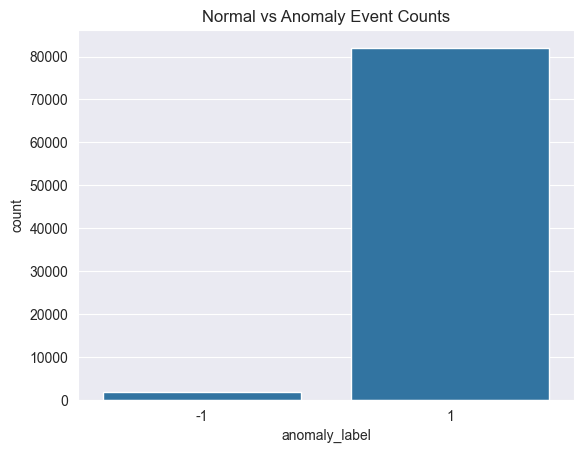

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_features, x = "anomaly_label")
plt.title("Normal vs Anomaly Event Counts")
plt.show()


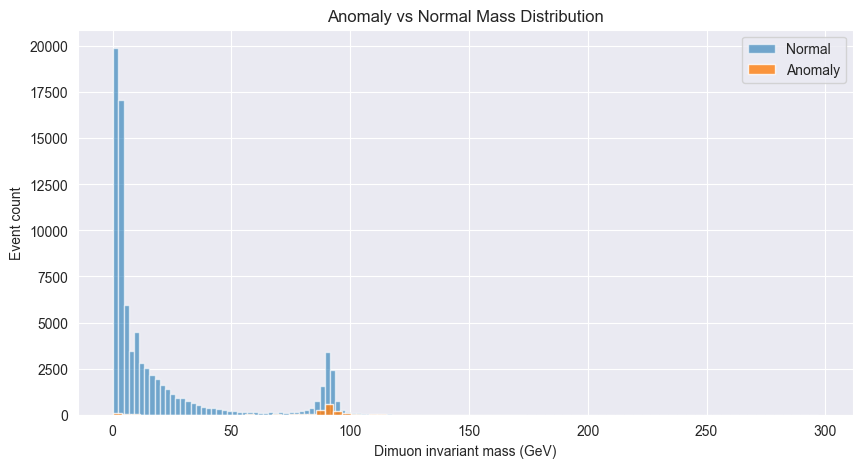

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_features[df_features["anomaly_label"] == 1]["M"], bins=80, alpha=0.6, label="Normal")
plt.hist(df_features[df_features["anomaly_label"] == -1]["M"], bins=80, alpha=0.8, label="Anomaly")
plt.xlabel("Dimuon invariant mass (GeV)")
plt.ylabel("Event count")
plt.title("Anomaly vs Normal Mass Distribution")
plt.legend()
plt.show()


In [19]:
output_anomaly_path = "../data/processed/dimuon_anomaly_results.parquet"
df_features.to_parquet(output_anomaly_path, index=False)

output_anomaly_path


'../data/processed/dimuon_anomaly_results.parquet'

In [20]:
import os
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


BASE_DIR = "/Users/ecemnurozen/Projects/cern-particle-anomaly-detection"
FEATURES_PATH = os.path.join(BASE_DIR, "data/features/dimuon_features.parquet")
MODEL_DIR = os.path.join(BASE_DIR, "api/models")

os.makedirs(MODEL_DIR, exist_ok=True)

df_features = pd.read_parquet(FEATURES_PATH)

numeric_cols = [
    "pt1","eta1","phi1","E1","Q1",
    "pt2","eta2","phi2","E2","Q2","M"
]

X = df_features[numeric_cols].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iforest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)
iforest.fit(X_scaled)

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(iforest, os.path.join(MODEL_DIR, "iforest.pkl"))

print("Scaler kaydedildi ✔️")
print("Isolation Forest kaydedildi ✔️")


Scaler kaydedildi ✔️
Isolation Forest kaydedildi ✔️
